In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    RepeatVector,
    TimeDistributed,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

I0000 00:00:1784119012.703104   32880 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784119012.704424   32880 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784119013.132250   32880 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784119016.539657   32880 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [3]:
if devices := tf.config.list_physical_devices("GPU"):
    print(f"Running on {devices}")
else:
    print("Running on CPU")

Running on CPU


E0000 00:00:1784057541.549954   51977 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# load API key
try:
    from google.colab import userdata
    IN_COLAB = True
except:
    IN_COLAB = False


if IN_COLAB:
    %pip install -q zarr xarray fsspec aiohttp earthkit
    cdsapi_key = userdata.get("CDS-API-KEY")
else:
    import os

    %load_ext dotenv
    %dotenv

    cdsapi_key = os.getenv("CDS-API-KEY")


In [ ]:
import xarray as xr

# https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land

# Choose chunking approach
# "geo" for Geo-chunked stores for access optimised along the time dimension (e.g. time-series at a point)
# "time" for Time-chunked stores for access optimised in spatial dimensions (e.g. a global map)
chunks = "geo" # or "time"

# Soil temperature
soil_temperature_url = f"https://arco.datastores.ecmwf.int/cadl-arco-{chunks}-006/arco/reanalysis_era5_land/sfc-soil-temperature/{chunks}Chunked.zarr"
# 2m temperature
var_2m_temperature_url = f"https://arco.datastores.ecmwf.int/cadl-arco-{chunks}-007/arco/reanalysis_era5_land/sfc-2m-temperature/{chunks}Chunked.zarr"
# Soil water
soil_water_url = f"https://arco.datastores.ecmwf.int/cadl-arco-{chunks}-005/arco/reanalysis_era5_land/sfc-soil-water/{chunks}Chunked.zarr"
# Radiation and heat
radiation_and_heat_url = f"https://arco.datastores.ecmwf.int/cadl-arco-{chunks}-010/arco/reanalysis_era5_land/sfc-radiation-heat/{chunks}Chunked.zarr"
# Snow
snow_url = f"https://arco.datastores.ecmwf.int/cadl-arco-{chunks}-030/arco/reanalysis_era5_land/sfc-snow/{chunks}Chunked.zarr"
# Wind
wind_url = f"https://arco.datastores.ecmwf.int/cadl-arco-{chunks}-008/arco/reanalysis_era5_land/sfc-wind/{chunks}Chunked.zarr"
# Pressure and precipitation
pressure_and_precipitation_url = f"https://arco.datastores.ecmwf.int/cadl-arco-{chunks}-009/arco/reanalysis_era5_land/sfc-pressure-precipitation/{chunks}Chunked.zarr"
# Skin temperature
skin_temperature_url = f"https://arco.datastores.ecmwf.int/cadl-arco-{chunks}-043/arco/reanalysis_era5_land/sfc-skin-temperature/{chunks}Chunked.zarr"

datasets = [
    xr.open_zarr(
        var_2m_temperature_url,
        consolidated=True,
        storage_options={
            "headers": {"Authorization": f"Bearer {cdsapi_key}"}
        }
    ),
    xr.open_zarr(
        wind_url,
        consolidated=True,
        storage_options={
            "headers": {"Authorization": f"Bearer {cdsapi_key}"}
        }
    ),
    xr.open_zarr(
        pressure_and_precipitation_url,
        consolidated=True,
        storage_options={
            "headers": {"Authorization": f"Bearer {cdsapi_key}"}
        }
    )
]

# only use data from Frankfurt am Main
ds = xr.merge(datasets)
# ds = ds_wind
ds = ds.sel(latitude=50.13, longitude=8.69, method="nearest")

features = {
    "d2m": "2m dewpoint in Kelvin",
    "t2m": "2m temperature in Kelvin",
    "u10": "10m wind eastward component i metre per second",
    "v10": "10m wind northward component i metre per second",
    "sp": "surface pressure in Pascal",
    "tp": "total precipitation in metre",
}

# Inspect the variables
ds.load()
ds

<xarray.Dataset> Size: 21MB
Dimensions:    (time: 670752)
Coordinates:
  * time       (time) datetime64[ns] 5MB 1950-01-02 ... 2026-07-09T23:00:00
    latitude   float64 8B 50.1
    longitude  float64 8B 8.7
Data variables:
    d2m        (time) float32 3MB 264.2 264.2 264.0 263.9 ... 285.1 285.2 285.2
    t2m        (time) float32 3MB 270.7 270.9 270.9 271.0 ... 294.9 293.8 292.8
    u10        (time) float32 3MB 0.2995 0.2431 0.4039 ... -2.071 -2.015 -1.652
    v10        (time) float32 3MB 1.074 1.561 1.862 ... -2.189 -1.892 -1.634
    sp         (time) float32 3MB 1.013e+05 1.013e+05 1.012e+05 ... 1e+05 1e+05
    tp         (time) float32 3MB 9.525e-09 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-10T00:00 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

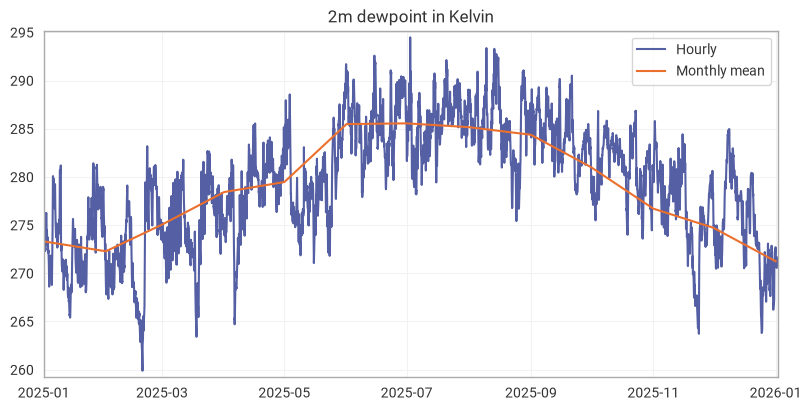

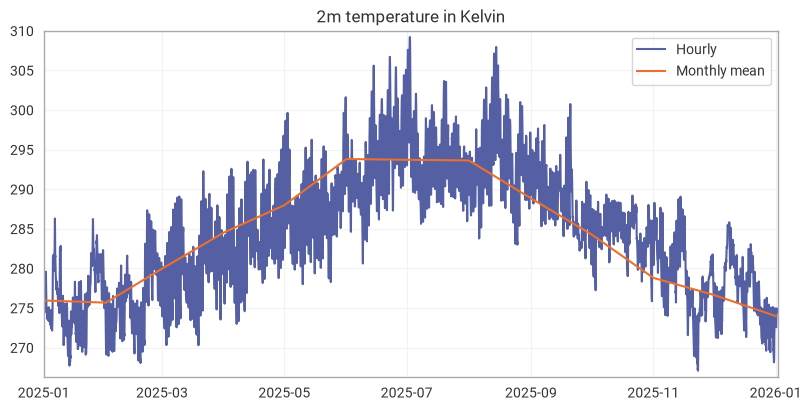

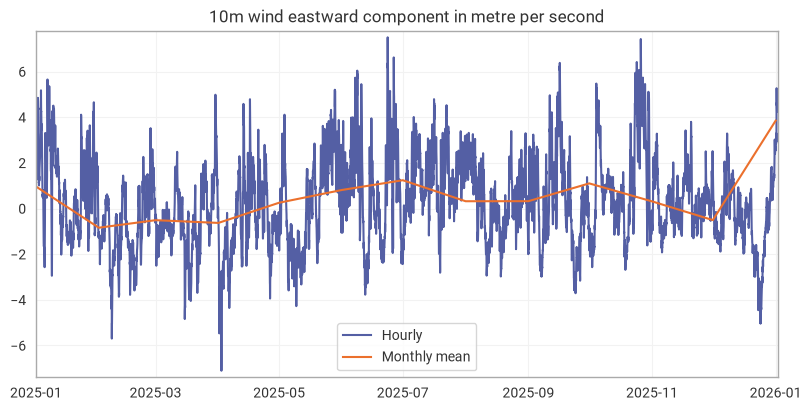

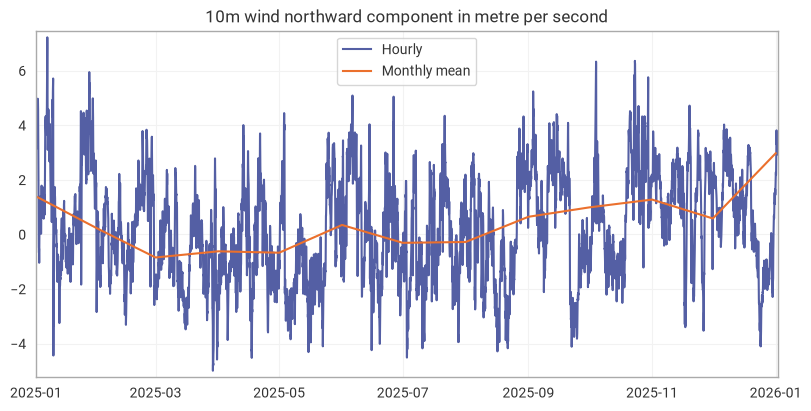

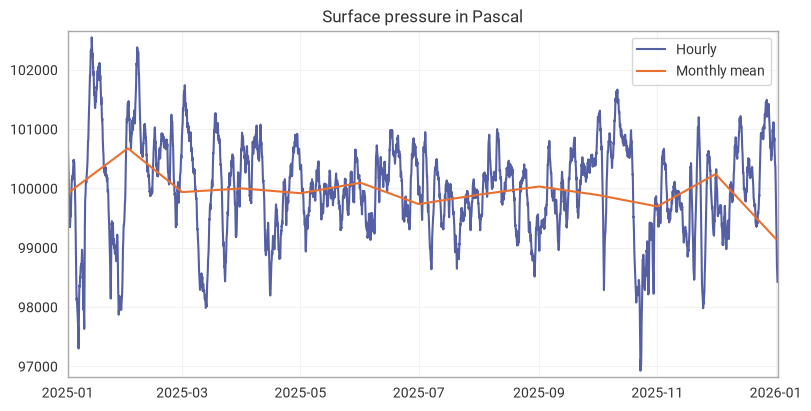

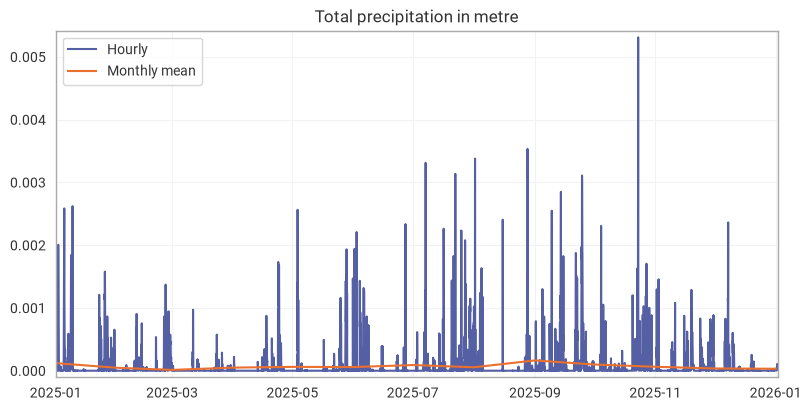

In [ ]:
# plot raw example data

from earthkit import plots as ekp
from earthkit import transforms as ekt

import warnings
warnings.filterwarnings(
    "ignore",
    message="TimeSeries is an experimental new feature*"
)

def plot_variable(variable_name, title):
    time = slice("2025-01-01", "2026-01-01")

    plot_data_hourly = ds[variable_name].sel(time=time)
    plot_data_monthly = ekt.temporal.monthly_mean(plot_data_hourly)

    chart = ekp.TimeSeries()

    chart.line(plot_data_hourly, label="Hourly")
    chart.line(plot_data_monthly, label="Monthly mean")

    chart.title(title)
    chart.legend()

    chart.show()

for name, title in features.items():
    plot_variable(name, title)

In [7]:
# move to pandas Dataframe
df = ds.to_dataframe().drop(columns=["latitude", "longitude"])
df

,d2m,t2m,u10,v10,sp,tp
time,,,,,,
1950-01-02 00:00:00,264.170776,270.692963,0.299500,1.073860,101314.890625,9.524911e-09
1950-01-02 01:00:00,264.159485,270.909180,0.243088,1.561325,101254.218750,0.000000e+00
1950-01-02 02:00:00,264.007355,270.862000,0.403870,1.861887,101176.328125,0.000000e+00
1950-01-02 03:00:00,263.883759,271.000610,0.635376,1.806019,101089.125000,0.000000e+00
1950-01-02 04:00:00,263.846527,271.042236,0.779175,1.775099,100988.156250,0.000000e+00
...,...,...,...,...,...,...
2026-07-09 19:00:00,285.110687,297.798615,-1.431854,-2.248797,99884.546875,0.000000e+00
2026-07-09 20:00:00,285.130859,296.224304,-1.812881,-2.265798,99946.867188,8.523493e-07
2026-07-09 21:00:00,285.147858,294.892548,-2.071350,-2.188504,99974.625000,0.000000e+00


In [8]:
# split the data chonologically
n = len(df)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

In [9]:
# scale data
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

In [ ]:
# create encoder-decoder windows
INPUT_LEN = 168      # 7 days
OUTPUT_LEN = 24      # next 24 hours


def create_sequences(data, input_len, output_len):

    X = []
    y = []

    total = len(data)

    for i in range(total - input_len - output_len + 1):

        encoder = data[i : i + input_len]

        decoder = data[
            i + input_len :
            i + input_len + output_len
        ]

        X.append(encoder)
        y.append(decoder)

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, INPUT_LEN, OUTPUT_LEN)
X_val, y_val = create_sequences(val_scaled, INPUT_LEN, OUTPUT_LEN)
X_test, y_test = create_sequences(test_scaled, INPUT_LEN, OUTPUT_LEN)

X_train.shape, y_train.shape

((469335, 168, 6), (469335, 24, 6))

In [11]:
# define model
n_features = X_train.shape[2]

inputs = Input(shape=(INPUT_LEN, n_features))

# Encoder
encoder = LSTM(
    128,
    activation="tanh"
)(inputs)

# Repeat context vector
decoder_input = RepeatVector(OUTPUT_LEN)(encoder)

# Decoder
decoder = LSTM(
    128,
    activation="tanh",
    return_sequences=True
)(decoder_input)

outputs = TimeDistributed(
    Dense(n_features)
)(decoder)

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 168, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 6)          │           774 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,478 (787.02 KB)

 Trainable params: 201,478 (787.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(name="rmse"), "mae"]
)

In [ ]:
# train model

joblib.dump(scaler, "scaler.pkl")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    shuffle=False
)

E0000 00:00:1784057911.862488   51977 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


5867/5867 ━━━━━━━━━━━━━━━━━━━━ 644s 109ms/step - loss: 0.3858 - mae: 0.3914 - root_mean_squared_error: 0.6211 - val_loss: 0.3983 - val_mae: 0.3932 - val_root_mean_squared_error: 0.6311


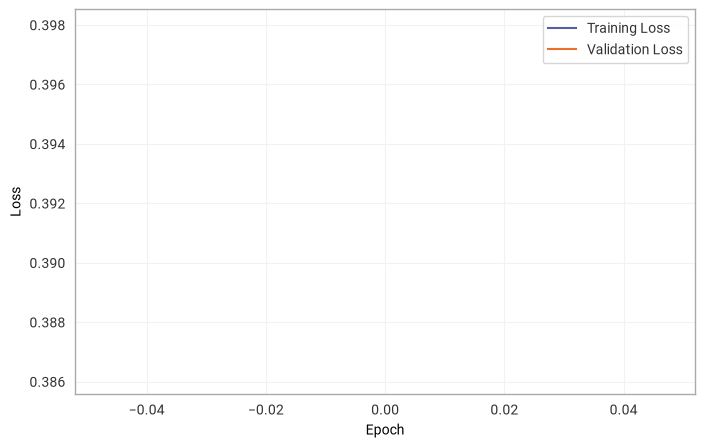

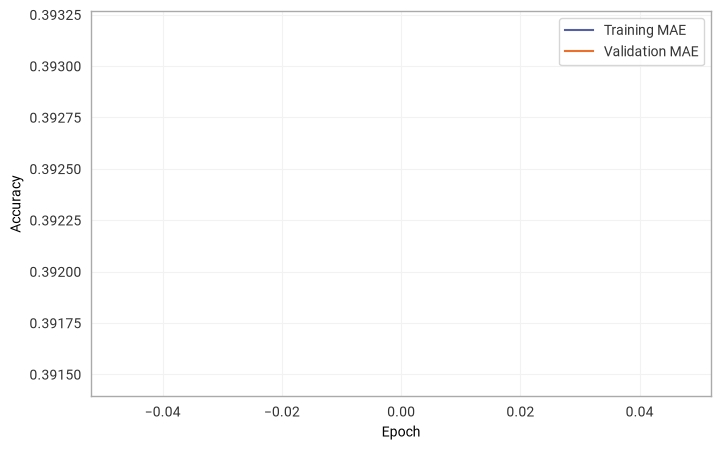

Keys: dict_keys(['loss', 'mae', 'root_mean_squared_error', 'val_loss', 'val_mae', 'val_root_mean_squared_error'])


In [ ]:
history_dict = history.history

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss (MSE)
axes[0].plot(history_dict["loss"], label="Train")
if "val_loss" in history_dict:
    axes[0].plot(history_dict["val_loss"], label="Validation")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True)

# RMSE
axes[1].plot(history_dict["rmse"], label="Train")
if "val_rmse" in history_dict:
    axes[1].plot(history_dict["val_rmse"], label="Validation")
axes[1].set_title("RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True)

# MAE
axes[2].plot(history_dict["mae"], label="Train")
if "val_mae" in history_dict:
    axes[2].plot(history_dict["val_mae"], label="Validation")
axes[2].set_title("MAE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# predict
y_pred = model.predict(X_test)

In [ ]:
# rescale features
n_samples, horizon, n_features = y_pred.shape

y_pred_inv = scaler.inverse_transform(
    y_pred.reshape(-1, n_features)
).reshape(n_samples, horizon, n_features)

y_true_inv = scaler.inverse_transform(
    y_test.reshape(-1, n_features)
).reshape(n_samples, horizon, n_features)

In [ ]:
# compute metrics
feature_names = [
    "d2m",
    "t2m",
    "u10",
    "v10",
    "sp",
    "tp"
]

for i, feature in enumerate(features):
    y_true = y_true_inv[:, :, i].ravel()
    y_hat = y_pred_inv[:, :, i].ravel()

    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))

    print(f"{feature:4s}  MAE={mae:.3f}   RMSE={rmse:.3f}")

In [ ]:
# plot predictions
sample = 0

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, ax in enumerate(axes.flat):
    ax.plot(
        y_true_inv[sample, :, i],
        label="True",
        linewidth=2
    )

    ax.plot(
        y_pred_inv[sample, :, i],
        "--",
        label="Prediction",
        linewidth=2
    )

    ax.set_title(feature_names[i])
    ax.set_xlabel("Forecast step")
    ax.grid(True)

axes[0,0].legend()

plt.tight_layout()
plt.show()

In [ ]:
# overall metrics
overall_mae = mean_absolute_error(
    y_true_inv.ravel(),
    y_pred_inv.ravel()
)

overall_rmse = np.sqrt(
    mean_squared_error(
        y_true_inv.ravel(),
        y_pred_inv.ravel()
    )
)

print(f"Overall MAE : {overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")

In [ ]:
# evaluate by forecast horizon

for step in range(horizon):
    mae = mean_absolute_error(
        y_true_inv[:, step, :].ravel(),
        y_pred_inv[:, step, :].ravel()
    )
    print(f"Step {step+1:2d}: MAE = {mae:.3f}")